## Video Game Sales & Ratings Analysis

**Author: Pranav Phulpagar**

**Date: February 19th 2026** 
 
## Project Overview
This analysis explores global video game sales data combined with critic and user ratings.
We'll investigate:
- Which genres and platforms dominate sales across different regions?
- How do critic/user scores correlate with commercial success?
- How has the gaming market evolved over the decades?
- Which publishers have been most successful?
  
**Dataset:** Video Game Sales with Ratings deereived from Kaggle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuring the plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Displaying the settings for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Data Loading & Initial Exploration

In [26]:
# Loading the dataset
df = pd.read_csv(r'D:\Game Sales\game-sales-analysis\data\Video_Games_Sales_as_at_22_Dec_2016.csv')

# Initial look at the data
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Column names:")
print(df.columns.tolist())

Dataset shape: 16719 rows, 16 columns

Column names:
['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating']


In [3]:
# This is to preview the first few rows
df.head(10)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26,NaN,NaN,NaN,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E
7,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32,87.0,80.0,8.4,594.0,Nintendo,E
9,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# For the data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  str    
 1   Platform         16719 non-null  str    
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  str    
 4   Publisher        16665 non-null  str    
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  str    
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  str    
 15  Rating           9950 non-null   str    
dtypes: float64(9), str(7)
memory usage: 2.0 MB


In [5]:
# In order to summarize stats for the numeric columns
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


## 2. Data Cleaning

Let's handle missing values, fix data types, and prepare the dataset for analysis.

In [6]:
# Checking the missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values Summary:
                 Missing Count  Missing %
User_Count                9129       54.6
Critic_Count              8582       51.3
Critic_Score              8582       51.3
Rating                    6769       40.5
User_Score                6704       40.1
Developer                 6623       39.6
Year_of_Release            269        1.6
Publisher                   54        0.3
Genre                        2        0.0
Name                         2        0.0


In [7]:
# First we will clean the dataset
df_clean = df.copy()

# Converting the Year of Release to numeric in order to eliminate the NA strings
df_clean['Year_of_Release'] = pd.to_numeric(df_clean['Year_of_Release'], errors='coerce')

# Drop rows where critical columns are missing
df_clean = df_clean.dropna(subset=['Year_of_Release', 'Genre', 'Name'])

# Converting year to integer
df_clean['Year_of_Release'] = df_clean['Year_of_Release'].astype(int)

# Convertings the User Score to numeric to avoid the TBD values User_Score to numeric
df_clean['User_Score'] = pd.to_numeric(df_clean['User_Score'], errors='coerce')

# Filter to reasonable year range
df_clean = df_clean[(df_clean['Year_of_Release'] >= 1980) & (df_clean['Year_of_Release'] <= 2016)]

print(f"Original dataset: {len(df)} rows")
print(f"Cleaned dataset: {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows ({((len(df) - len(df_clean)) / len(df) * 100):.1f}%)")

Original dataset: 16719 rows
Cleaned dataset: 16444 rows
Removed: 275 rows (1.6%)


In [8]:
# A small sanity check on the new clearned dataset
print("Year range:", df_clean['Year_of_Release'].min(), "-", df_clean['Year_of_Release'].max())
print("Unique genres:", df_clean['Genre'].nunique())
print("Unique platforms:", df_clean['Platform'].nunique())
print("Unique publishers:", df_clean['Publisher'].nunique())
print("\nGenres:", sorted(df_clean['Genre'].unique()))

Year range: 1980 - 2016
Unique genres: 12
Unique platforms: 31
Unique publishers: 579

Genres: ['Action', 'Adventure', 'Fighting', 'Misc', 'Platform', 'Puzzle', 'Racing', 'Role-Playing', 'Shooter', 'Simulation', 'Sports', 'Strategy']


## 3. Market Evolution Over Time

How has the gaming industry grown and changed over the decades?

In [9]:
import os

# Use absolute path to your project's images folder
images_dir = r'D:\Game Sales\game-sales-analysis\images'
os.makedirs(images_dir, exist_ok=True)

print("Folder created at:", images_dir)
print("Contents:", os.listdir(images_dir))

IMG = r'D:\Game Sales\game-sales-analysis\images'

Folder created at: D:\Game Sales\game-sales-analysis\images
Contents: ['releases_per_year.png']


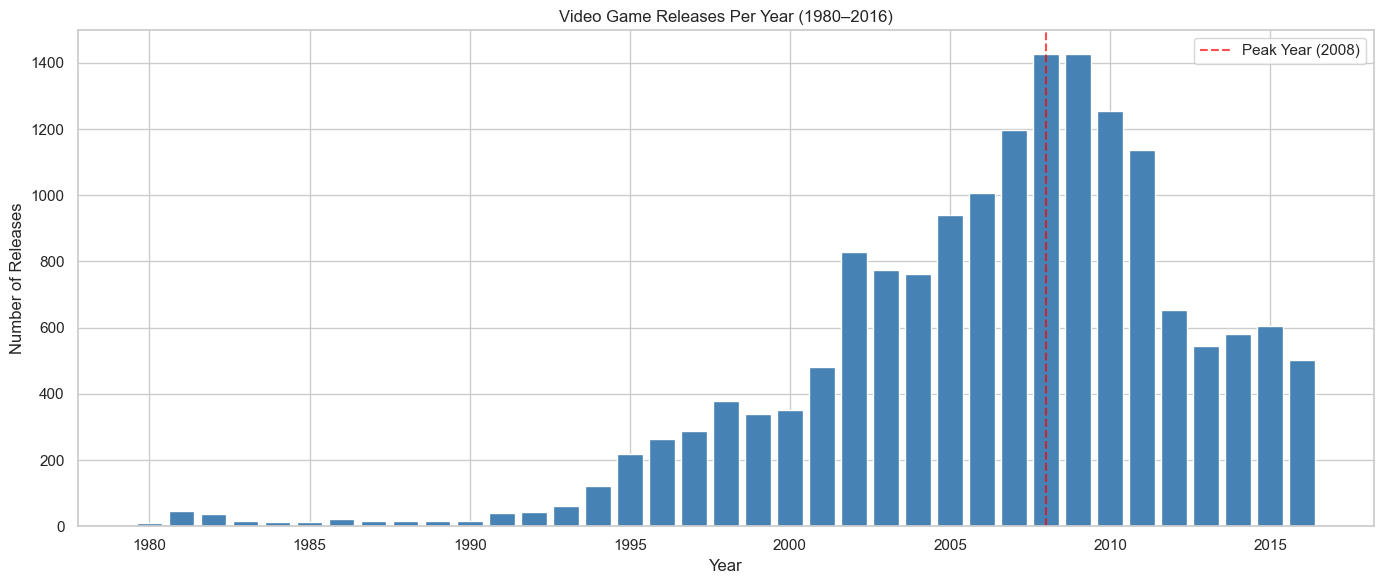

Peak year: 2008 with 1427 releases


In [27]:
# Number of game that were released per year
releases_by_year = df_clean.groupby('Year_of_Release').size()

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(releases_by_year.index, releases_by_year.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Releases')
ax.set_title('Video Game Releases Per Year (1980–2016)')
ax.axvline(x=2008, color='red', linestyle='--', alpha=0.7, label='Peak Year (2008)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{IMG}/releases_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak year: {releases_by_year.idxmax()} with {releases_by_year.max()} releases")

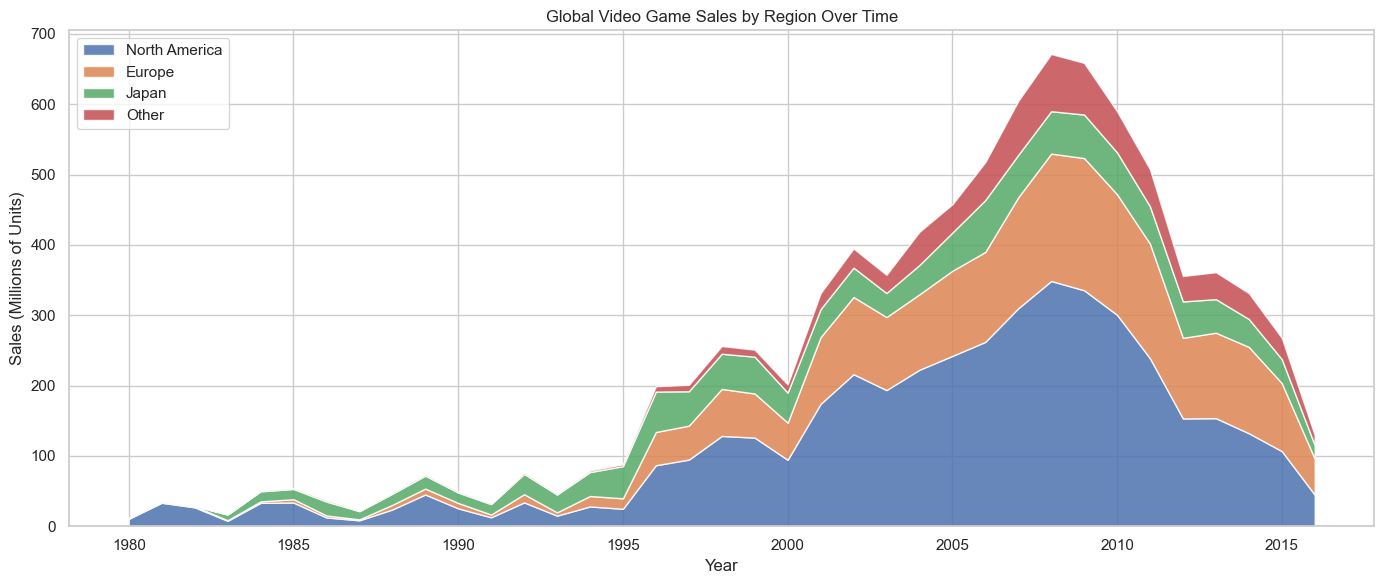

In [19]:
# Global sales over time by region
sales_by_year = df_clean.groupby('Year_of_Release')[
    ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
].sum()

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(
    sales_by_year.index,
    sales_by_year['NA_Sales'],
    sales_by_year['EU_Sales'],
    sales_by_year['JP_Sales'],
    sales_by_year['Other_Sales'],
    labels=['North America', 'Europe', 'Japan', 'Other'],
    alpha=0.85
)
ax.set_xlabel('Year')
ax.set_ylabel('Sales (Millions of Units)')
ax.set_title('Global Video Game Sales by Region Over Time')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(f'{IMG}/sales_by_region_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Observations — Market Evolution
 
- The industry saw explosive growth from 2000 to 2008, peaking around 2007-2009.
- Post-2010 decline likely reflects the shift to digital distribution (which this dataset may not fully capture) and the rise of mobile gaming.
- North America has consistently been the largest market.
- Japan's share has decreased over time relative to the Western markets.

## 4. Genre Analysis

Which genres dominate in terms of sales volume, and does this vary by region?

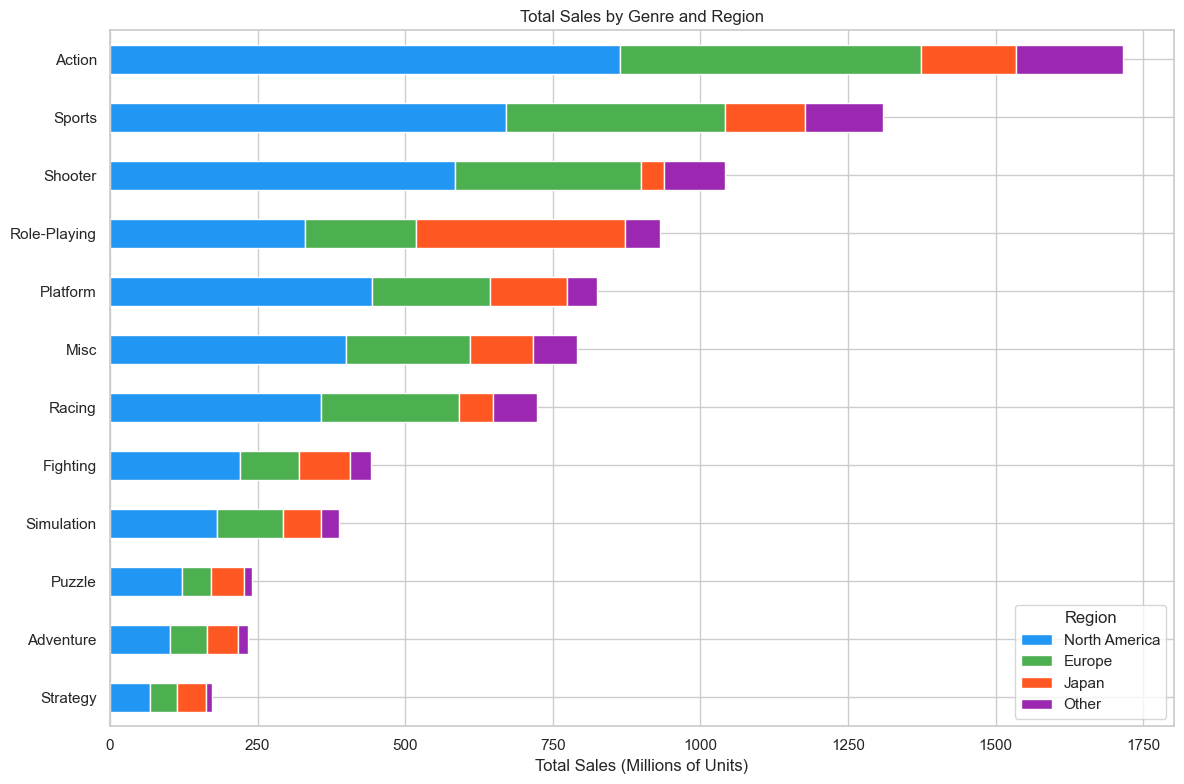

In [20]:
# Top genres by global sales
genre_sales = df_clean.groupby('Genre')[
    ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
].sum().sort_values('Global_Sales', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
genre_sales[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].plot(
    kind='barh', stacked=True, ax=ax,
    color=['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']
)
ax.set_xlabel('Total Sales (Millions of Units)')
ax.set_ylabel('')
ax.set_title('Total Sales by Genre and Region')
ax.legend(title='Region', labels=['North America', 'Europe', 'Japan', 'Other'])
plt.tight_layout()
plt.savefig(f'{IMG}/genre_sales_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Genre popularity differences between regions
# Normalizing the sales within each region to show percentage share
region_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales']
genre_share = df_clean.groupby('Genre')[region_cols].sum()
genre_share_pct = genre_share.div(genre_share.sum(axis=0), axis=1) * 100

# We are showing the top 5 genres per region
print("=== Top 5 Genres by Region (% of regional sales) ===\n")
for col, name in zip(region_cols, ['North America', 'Europe', 'Japan']):
    top5 = genre_share_pct[col].sort_values(ascending=False).head(5)
    print(f"{name}:")
    for genre, pct in top5.items():
        print(f"  {genre:20s} {pct:.1f}%")
    print()

=== Top 5 Genres by Region (% of regional sales) ===

North America:
  Action               19.9%
  Sports               15.5%
  Shooter              13.5%
  Platform             10.2%
  Misc                 9.2%

Europe:
  Action               21.3%
  Sports               15.5%
  Shooter              13.1%
  Racing               9.8%
  Misc                 8.8%

Japan:
  Role-Playing         27.4%
  Action               12.4%
  Sports               10.5%
  Platform             10.1%
  Misc                 8.3%



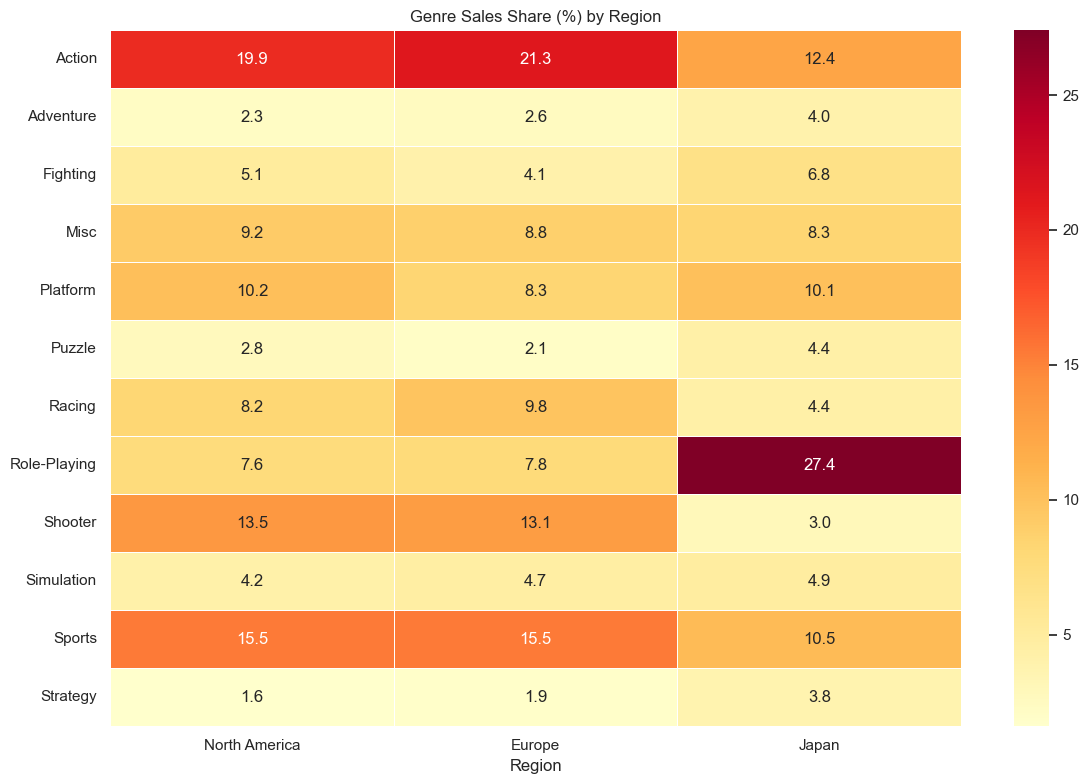

In [21]:
# Formulating a Heatmap to showcase genre preference by region
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    genre_share_pct.round(1),
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax
)
ax.set_title('Genre Sales Share (%) by Region')
ax.set_xlabel('Region')
ax.set_ylabel('')
ax.set_xticklabels(['North America', 'Europe', 'Japan'])
plt.tight_layout()
plt.savefig(f'{IMG}/genre_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Observations — Genre Analysis
- Action and Sports genres lead globally in raw sales.
- Japan has a significantly higher preference for Role-Playing games compared to Western markets.
- Shooter games perform much stronger in NA/EU than in Japan.
- This kind of regional genre preference data is critical for publishers deciding which markets to target.

## 5. Ratings vs. Sales — Do Good Games Sell More? 
Let's examine the relationship between critic scores, user scores, and commercial performance.

Games with both critic and user scores: 6894


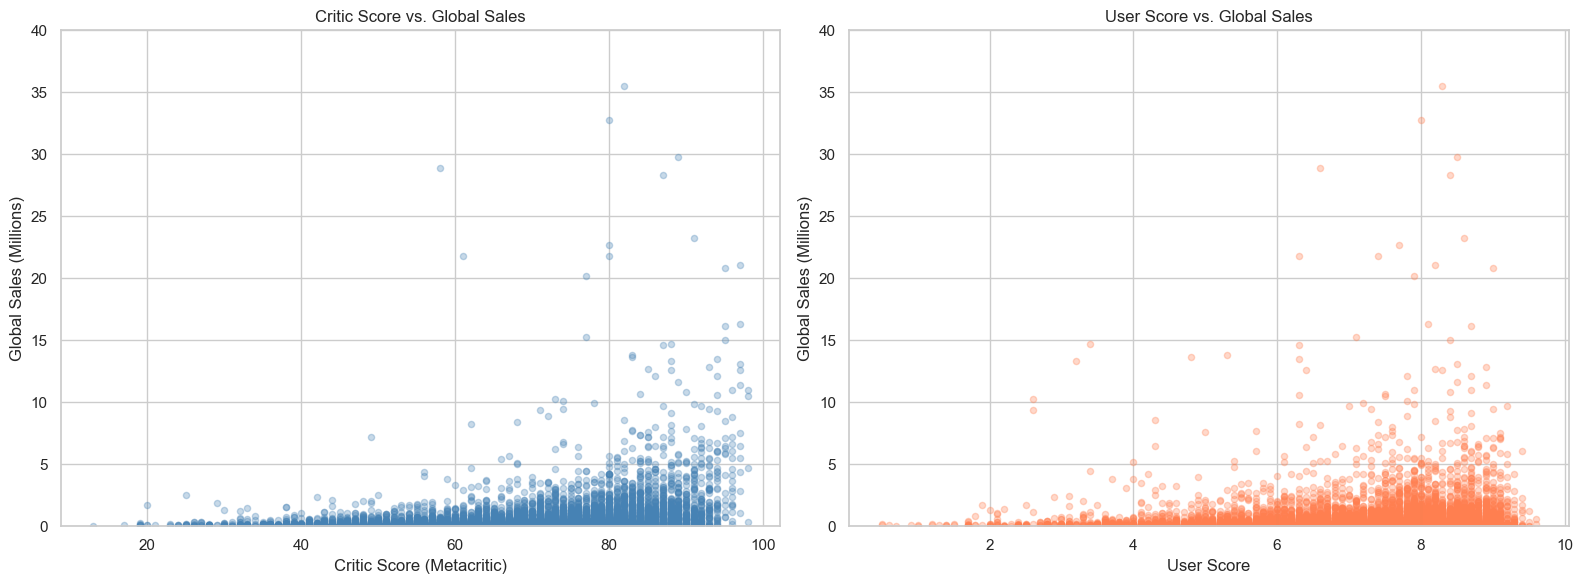


Correlation — Critic Score vs Global Sales: 0.237
Correlation — User Score vs Global Sales:   0.088


In [22]:
# Filtering to rows that have both scores and sales
df_scored = df_clean.dropna(subset=['Critic_Score', 'User_Score', 'Global_Sales']).copy()
print(f"Games with both critic and user scores: {len(df_scored)}")

# Scatter Plot: Critic Score vs Global Sales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Critic Score
axes[0].scatter(
    df_scored['Critic_Score'], df_scored['Global_Sales'],
    alpha=0.3, s=20, color='steelblue'
)
axes[0].set_xlabel('Critic Score (Metacritic)')
axes[0].set_ylabel('Global Sales (Millions)')
axes[0].set_title('Critic Score vs. Global Sales')
axes[0].set_ylim(0, 40)  # Cap for readability (outliers exist)

# User Score
axes[1].scatter(
    df_scored['User_Score'], df_scored['Global_Sales'],
    alpha=0.3, s=20, color='coral'
)
axes[1].set_xlabel('User Score')
axes[1].set_ylabel('Global Sales (Millions)')
axes[1].set_title('User Score vs. Global Sales')
axes[1].set_ylim(0, 40)

plt.tight_layout()
plt.savefig(f'{IMG}/scores_vs_sales.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation values
print(f"\nCorrelation — Critic Score vs Global Sales: "
      f"{df_scored['Critic_Score'].corr(df_scored['Global_Sales']):.3f}")
print(f"Correlation — User Score vs Global Sales:   "
      f"{df_scored['User_Score'].corr(df_scored['Global_Sales']):.3f}")

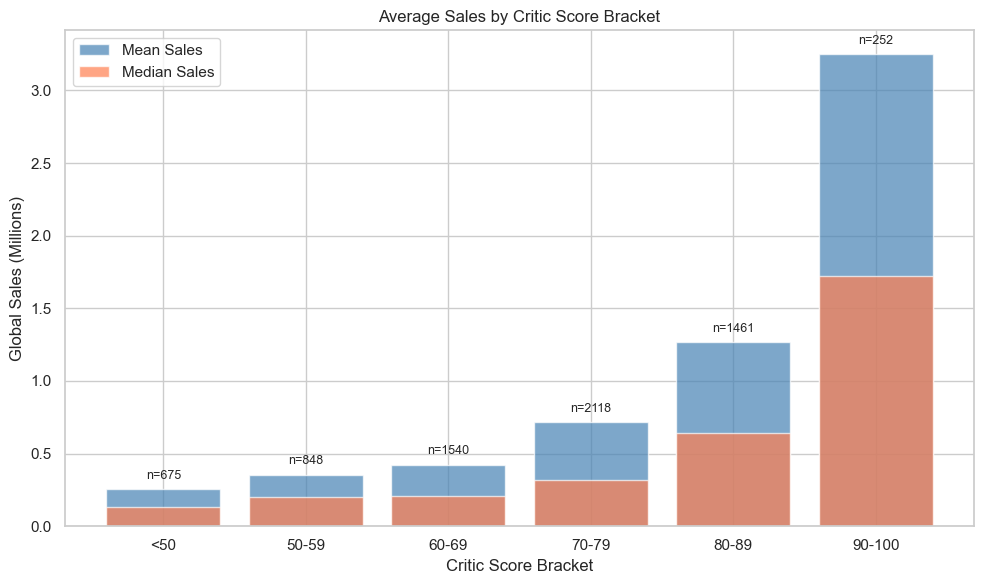

               Mean Sales (M)  Median Sales (M)  Game Count
Score_Bracket                                              
<50                     0.257             0.130         675
50-59                   0.355             0.200         848
60-69                   0.425             0.210        1540
70-79                   0.715             0.320        2118
80-89                   1.270             0.640        1461
90-100                  3.251             1.725         252


In [23]:
# Average sales by score bracket
df_scored['Score_Bracket'] = pd.cut(
    df_scored['Critic_Score'],
    bins=[0, 50, 60, 70, 80, 90, 100],
    labels=['<50', '50-59', '60-69', '70-79', '80-89', '90-100']
)

bracket_stats = df_scored.groupby('Score_Bracket', observed=True)['Global_Sales'].agg(
    ['mean', 'median', 'count']
).round(3)
bracket_stats.columns = ['Mean Sales (M)', 'Median Sales (M)', 'Game Count']

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(bracket_stats))
ax.bar(x, bracket_stats['Mean Sales (M)'], color='steelblue',
       alpha=0.7, label='Mean Sales')
ax.bar(x, bracket_stats['Median Sales (M)'], color='coral',
       alpha=0.7, label='Median Sales')
ax.set_xticks(x)
ax.set_xticklabels(bracket_stats.index)
ax.set_xlabel('Critic Score Bracket')
ax.set_ylabel('Global Sales (Millions)')
ax.set_title('Average Sales by Critic Score Bracket')
ax.legend()

# Let's add the game counts on top of the bars
for i, count in enumerate(bracket_stats['Game Count']):
    ax.text(i, bracket_stats['Mean Sales (M)'].iloc[i] + 0.05,
            f'n={count}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{IMG}/sales_by_score_bracket.png', dpi=150, bbox_inches='tight')
plt.show()

print(bracket_stats)

### Key Observations — Ratings vs. Sales
- There is a positive but moderate correlation between critic scores and sales.
- The mean vs. median gap in higher score brackets suggests a few blockbuster titles skew the average — most well-reviewed games still sell modestly.
- User scores show a weaker correlation with sales than critic scores.
- **Some takeaway for studios:** Good reviews help, but they don't guarantee commercial success. Marketing, franchise recognition, and platform availability likely matter just as much.


## 6. Platform & Publisher Analysis

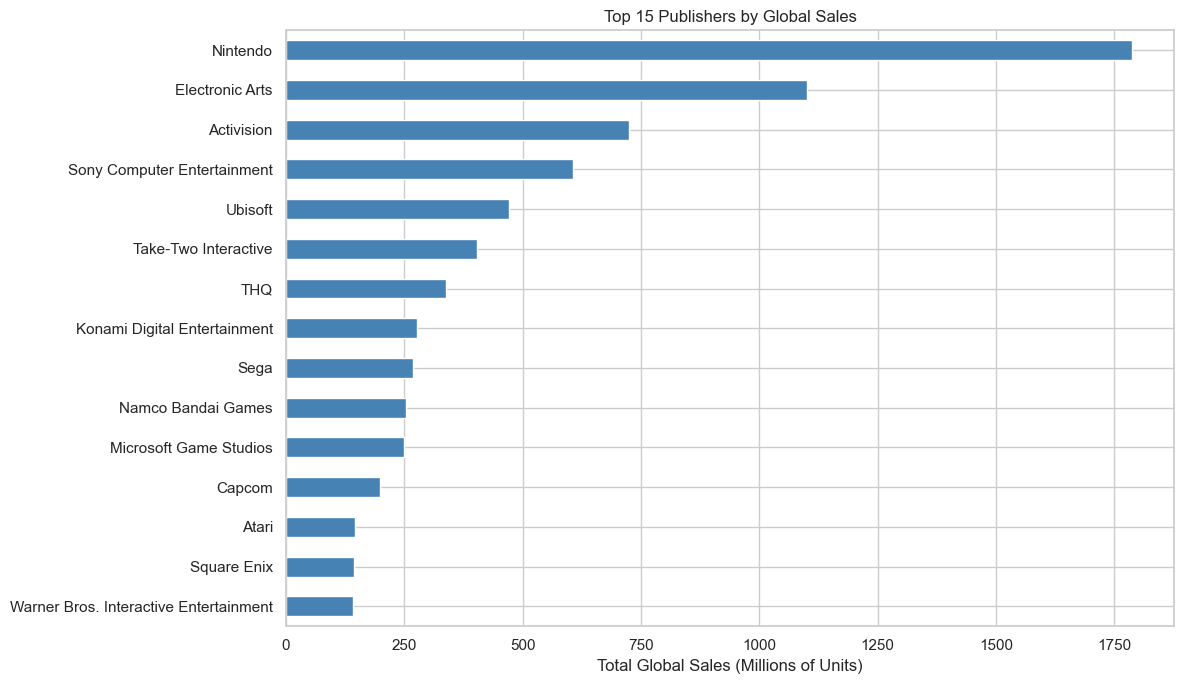

In [24]:
# Top 15 publishers by global sales
top_pub = df_clean.groupby('Publisher')['Global_Sales'].sum() \
    .sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
top_pub.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Total Global Sales (Millions of Units)')
ax.set_ylabel('')
ax.set_title('Top 15 Publishers by Global Sales')
plt.tight_layout()
plt.savefig(f'{IMG}/top_publishers.png', dpi=150, bbox_inches='tight')
plt.show()

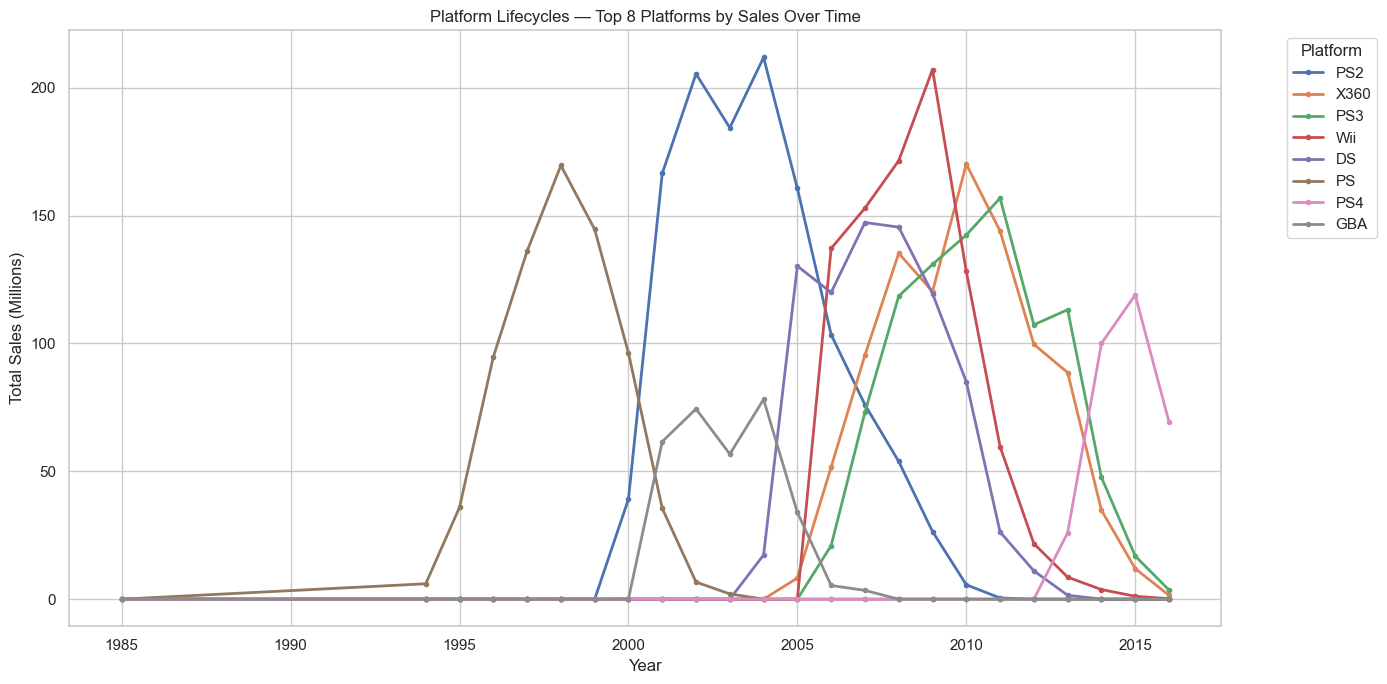

In [25]:
# Platform lifecycle — top platforms by total sales, shown over time
top_platforms = df_clean.groupby('Platform')['Global_Sales'].sum() \
    .sort_values(ascending=False).head(8).index.tolist()

plat_year = df_clean[df_clean['Platform'].isin(top_platforms)] \
    .groupby(['Year_of_Release', 'Platform'])['Global_Sales'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
for plat in top_platforms:
    if plat in plat_year.columns:
        ax.plot(plat_year.index, plat_year[plat], marker='o', markersize=3,
                linewidth=2, label=plat)

ax.set_xlabel('Year')
ax.set_ylabel('Total Sales (Millions)')
ax.set_title('Platform Lifecycles — Top 8 Platforms by Sales Over Time')
ax.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{IMG}/platform_lifecycles.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary & Conclusions

### Key Findings

1. **Market peaked around 2007–2009** in terms of physical game releases and unit sales, with a decline afterward likely driven by the shift to digital distribution and mobile gaming.

2. **North America dominates global sales**, but regional genre preferences differ significantly — particularly Japan's strong preference for RPGs.
 
3. **Critic scores have a moderate positive correlation with sales**, but the relationship is far from deterministic. The gap between mean and median sales at every score bracket shows that a few mega-hits drive the averages.

4. **Platform lifecycles are clearly visible in the data**, with distinct generational waves (PS2 → Wii/X360/PS3 → PS4/XOne).

5. **Nintendo, EA, and Activision** have historically led in total sales volume, each with very different genre strategies.

### Limitations
- Dataset only covers physical sales through 2016 — digital sales (Steam, PSN, eShop) are not included.
- Post-2013 data may be incomplete.
- User scores have many missing values, limiting that analysis.

### Potential Next Steps
- Combine with digital sales data for a more complete picture.
- Time-series forecasting of genre trends.
- Deeper publisher strategy analysis (genre diversification over time).